# Importing Libraries

In [ ]:
# Core Data Manipulation
import numpy as np
import pandas as pd

# Machine Learning & Clustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Data Visualization
import matplotlib.pyplot as plt

# Geospatial Analysis
import geopandas as gpd
from keplergl import KeplerGl


# Loading DF

In [2]:
norm_df = pd.read_csv('..\\Data\\NMF_STREET.csv', low_memory=False)
nyc_map = gpd.read_file("..\\Data\\Modified Zip Code Tabulation Areas (MODZCTA).geojson")
streets_projected = gpd.read_file("..\\Data\\nyc_clustered_streets.gpkg")

# Clustering Hierarchical

In [3]:
# Print clustering output
def output(labels):
    labels = pd.Series(labels)
    print("The labels:\n", labels)
    print("===================")
    print("Cluster Counts:\n", labels.value_counts())


In [4]:
# Drop incident zip column
Features = norm_df.drop("Street_Name", axis=1)

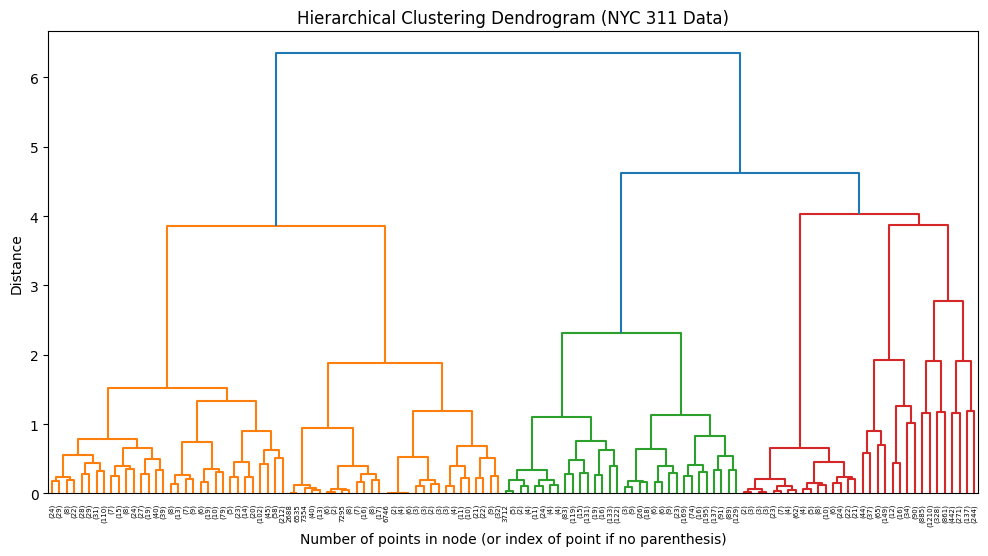

In [5]:
# Fitting the model 
agg = AgglomerativeClustering(
    distance_threshold=0,
    n_clusters=None,
    compute_distances=True
)
agg.fit(Features)

# Dendrogram plot func
def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


# Plot the Dendrogram
plt.figure(figsize=(12, 6))
plot_dendrogram(agg, truncate_mode='level', p=6) # p is rendreing limit
plt.title("Hierarchical Clustering Dendrogram (NYC 311 Data)")
plt.xlabel("Number of points in node (or index of point if no parenthesis)")
plt.ylabel("Distance")
plt.show()


## Silhouette Score

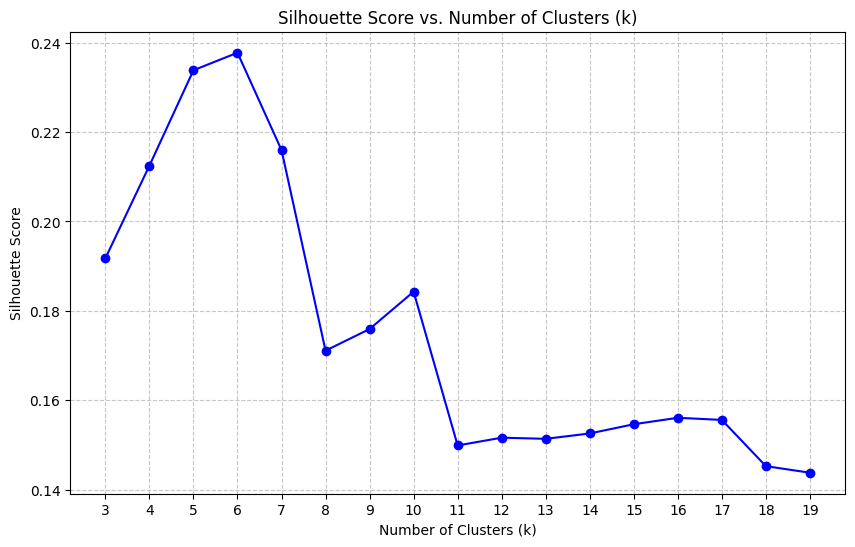

In [6]:
score_lst = []
k_range = range(3, 20) # Define the range once to keep it consistent

for k in k_range:
    # Get labels
    clustering = AgglomerativeClustering(n_clusters=k).fit(Features)
    labels = clustering.fit_predict(Features)
    norm_df["Cluster"] = labels

    # Calculate the Silhouette Score
    score = silhouette_score(Features, labels)
    score_lst.append(score)

# Create the x-axis list (number of clusters)
k_lst = list(k_range)    

# --- Make the plot ---
plt.figure(figsize=(10, 6)) # Set the figure size
plt.plot(k_lst, score_lst, marker='o', linestyle='-', color='b') # Added points 'o' for visibility

# Add labels and title
plt.title('Silhouette Score vs. Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

# Formatting to make it look nice
plt.xticks(k_lst) # Shows every 'k' value on the x-axis
plt.grid(True, linestyle='--', alpha=0.7) # Adds a subtle grid

# Display the plot
plt.show()

## Running Clustring for 7 clusters

In [7]:
# Get labels
final_clustering = AgglomerativeClustering(n_clusters = 7)
labels = final_clustering.fit_predict(Features)
norm_df['Cluster'] = labels
output(labels)

The labels:
 0       0
1       3
2       6
3       6
4       6
       ..
8067    0
8068    6
8069    3
8070    6
8071    2
Length: 8072, dtype: int64
Cluster Counts:
 6    3284
0    1693
2    1094
5    1090
1     447
4     257
3     207
Name: count, dtype: int64


In [8]:
# Define the outlier clusters we want to push to the end
vc = norm_df['Cluster'].value_counts()
outlier_clusters = singleton_labels = vc[vc == 1].index.tolist()

# Get a list of all current clusters in the dataframe, sorted numerically
current_clusters = sorted(norm_df['Cluster'].dropna().unique())

# Separate the "main" clusters from the "outlier" clusters
main_clusters = [c for c in current_clusters if c not in outlier_clusters]
outliers_present = [c for c in outlier_clusters if c in current_clusters]

# Create a new ordered list: Main clusters first, followed by outliers at the end
new_cluster_order = main_clusters + outliers_present

# Create a mapping dictionary {old_id: new_id}
# This automatically assigns 0, 1, 2... etc.
# THe main clusters will become 0 to 10, and the outliers will become 11, 12, 13, 14.
cluster_mapping = {old_id: new_id for new_id, old_id in enumerate(new_cluster_order)}

# Let's print the mapping so we can verify it worked exactly as you wanted
print("Here is how the clusters are being renumbered:")
for old, new in cluster_mapping.items():
    print(f"Old Cluster {old} --> New Cluster {new}")

# Apply the mapping to overwrite the old numbers
norm_df['Cluster'] = norm_df['Cluster'].map(cluster_mapping)

Here is how the clusters are being renumbered:
Old Cluster 0 --> New Cluster 0
Old Cluster 1 --> New Cluster 1
Old Cluster 2 --> New Cluster 2
Old Cluster 3 --> New Cluster 3
Old Cluster 4 --> New Cluster 4
Old Cluster 5 --> New Cluster 5
Old Cluster 6 --> New Cluster 6


In [9]:
# Combine your features and the new hierarchical labels
features_with_labels = Features.copy()
features_with_labels['Cluster'] = labels

# Calculate the manual "centroids" (the mathematical average of each cluster)
hierarchical_centroids = features_with_labels.groupby('Cluster').mean()

# Reuse our persona analysis function
def analyze_hierarchical_personas(centroid_dataframe, top_n=3):
    """
    Identifies the top N driving features for each hierarchical cluster.
    """
    print(f"--- Top {top_n} Defining 311 Complaints per Hierarchical Cluster ---\n")
    
    # Iterate through the index (which now contains the cluster numbers 0 through 9)
    for cluster_id in centroid_dataframe.index:
        
        # Isolate the current cluster's averages
        cluster_profile = centroid_dataframe.loc[cluster_id]
        
        # Sort to find the highest dominating complaints
        top_features = cluster_profile.sort_values(ascending=False).head(top_n)
        
        print(f"Cluster {cluster_id}:")
        for feature, value in top_features.items():
            print(f"  * {feature}: {value:.4f}")
            
        print("-" * 40)

# Running the func 
analyze_hierarchical_personas(hierarchical_centroids, top_n=4)

--- Top 4 Defining 311 Complaints per Hierarchical Cluster ---

Cluster 0:
  * Profile_7 (Residential_and_Mixed_Use_Pct): 0.0998
  * Profile_8 (Weekend_Ratio): 0.0739
  * Profile_2 (Noise_Pct): 0.0375
  * Profile_5 (Street_and_Transportation_Pct): 0.0218
----------------------------------------
Cluster 1:
  * Profile_8 (Weekend_Ratio): 0.1941
  * Profile_2 (Noise_Pct): 0.0560
  * Profile_3 (Other/Misc_LType_Pct): 0.0225
  * Profile_5 (Street_and_Transportation_Pct): 0.0217
----------------------------------------
Cluster 2:
  * Profile_6 (Street_and_Infrastructure_Pct): 0.0548
  * Profile_8 (Weekend_Ratio): 0.0397
  * Profile_3 (Other/Misc_LType_Pct): 0.0296
  * Profile_9 (Sanitation_and_Trash_Pct): 0.0219
----------------------------------------
Cluster 3:
  * Profile_6 (Street_and_Infrastructure_Pct): 0.2114
  * Profile_8 (Weekend_Ratio): 0.0281
  * Profile_3 (Other/Misc_LType_Pct): 0.0267
  * Profile_2 (Noise_Pct): 0.0066
----------------------------------------
Cluster 4:
  * Profi

## Visualizations ( Maps )

In [10]:
# ============================================================
# STEP 1 — Filter streets to those in our data
# ============================================================

streets_to_plot = streets_projected[
    streets_projected['full_street_name'].isin(norm_df['Street_Name'])
][['full_street_name', 'geometry']].copy()

streets_to_plot = streets_to_plot.dissolve(by='full_street_name').reset_index()

# ============================================================
# STEP 2 — Merge cluster info
# ============================================================

streets_to_plot = streets_to_plot.merge(
    norm_df[['Street_Name', 'Cluster']],
    left_on='full_street_name',
    right_on='Street_Name',
    how='left'
)

streets_to_plot['Cluster'] = 'Cluster ' + streets_to_plot['Cluster'].astype(str)

# ============================================================
# STEP 3 — Reproject to 4326
# ============================================================

streets_to_plot = streets_to_plot.to_crs(epsg=4326)


print(f"Rendering {len(streets_to_plot):,} streets across {streets_to_plot['Cluster'].nunique()} clusters...")

# ============================================================
# STEP 4 — Kepler.gl
# ============================================================

# ============================================================
# Config — color polygons by Cluster field
# ============================================================

kepler_config = {
    'version': 'v1',
    'config': {
        'visState': {
            'layers': [{
                'type': 'geojson',
                'config': {
                    'dataId': 'NYC Streets by Cluster',
                    'label': 'NYC Streets by Cluster',
                    'isVisible': True,
                    'visConfig': {
                        'opacity':        0.85,
                        'strokeOpacity':  0.8,
                        'thickness':      0.5,
                        'stroked':        True,
                        'filled':         True,
                        'enable3d':       False,
                        'colorRange': {
                            'name':     'ColorBrewer Set1-9',
                            'type':     'qualitative',
                            'category': 'ColorBrewer',
                            'colors':   [
                                '#e41a1c','#377eb8','#4daf4a',
                                '#984ea3','#ff7f00','#ffff33',
                                '#a65628','#f781bf','#999999'
                            ]
                        },
                    },
                },
                'visualChannels': {
                    'colorField': {
                        'name': 'Cluster',   # color by this column
                        'type': 'string'
                    },
                    'colorScale': 'ordinal', 
                }
            }]
        },
        'mapState': {
            'latitude':  40.73,
            'longitude': -73.93,
            'zoom':      10
        },
        'mapStyle': {
            'styleType': 'dark'  # 'dark', 'light', 'muted', 'satellite'
        }
    }
}

# ============================================================
# Render
# ============================================================

kepler_map = KeplerGl(height=750, config=kepler_config)

kepler_map.add_data(
    data=streets_to_plot[['full_street_name', 'Cluster', 'geometry']],
    name='NYC Streets by Cluster'
)

kepler_map

Rendering 8,072 streets across 7 clusters...
User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


KeplerGl(config={'version': 'v1', 'config': {'visState': {'layers': [{'type': 'geojson', 'config': {'dataId': …